<a href="https://colab.research.google.com/github/iamviplavkr/viplav_kumar_23FE10CSE00421_ML/blob/main/Smart_Parking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('/content/IIoT_Smart_Parking_Management.csv')

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 28)

Column names:
 ['Timestamp', 'Parking_Spot_ID', 'Sensor_Reading_Proximity', 'Sensor_Reading_Pressure', 'Vehicle_Type_Weight', 'Vehicle_Type_Height', 'User_Type', 'Weather_Temperature', 'Weather_Precipitation', 'Nearby_Traffic_Level', 'Entry_Time', 'Exit_Time', 'Electric_Vehicle', 'Reserved_Status', 'Occupancy_Rate', 'Payment_Amount', 'Parking_Lot_Section', 'Payment_Status', 'Occupancy_Status', 'Vehicle_Type', 'Parking_Violation', 'Sensor_Reading_Ultrasonic', 'Parking_Duration', 'Environmental_Noise_Level', 'Dynamic_Pricing_Factor', 'Spot_Size', 'Proximity_To_Exit', 'User_Parking_History']

First 5 rows:


,Timestamp,Parking_Spot_ID,Sensor_Reading_Proximity,Sensor_Reading_Pressure,Vehicle_Type_Weight,Vehicle_Type_Height,User_Type,Weather_Temperature,Weather_Precipitation,Nearby_Traffic_Level,...,Occupancy_Status,Vehicle_Type,Parking_Violation,Sensor_Reading_Ultrasonic,Parking_Duration,Environmental_Noise_Level,Dynamic_Pricing_Factor,Spot_Size,Proximity_To_Exit,User_Parking_History
0,2021-01-01 00:00:00.000000000,20,1.023651,1.541461,1831.770127,4.392528,Visitor,18.092553,1,Low,...,Occupied,Car,0,102.951052,4,55.620740,0.8,Standard,6.610474,6.660310
1,2021-01-02 06:39:16.756756756,49,3.903349,1.621719,1330.815754,4.595638,Registered,13.397533,0,Low,...,Occupied,Car,0,87.559131,3,56.682386,1.2,Compact,8.678719,6.766187
2,2021-01-03 13:18:33.513513513,38,10.315709,6.292374,1255.134827,4.313721,Registered,21.687410,0,High,...,Vacant,Car,1,100.061854,5,59.239322,0.8,Standard,13.795262,-0.910052
3,2021-01-04 19:57:50.270270270,31,6.588039,1.659870,1523.442919,3.567329,Visitor,18.683461,0,Medium,...,Vacant,Motorcycle,1,110.594598,2,44.545155,0.8,Standard,1.678721,10.415888
4,2021-01-06 02:37:07.027027027,8,8.213969,3.278467,1758.490837,5.145836,Visitor,19.214876,0,High,...,Occupied,Car,0,84.786963,2,48.012604,0.8,Standard,20.012252,4.355544


In [2]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing:", df.isnull().sum().sum())
# Output: 0 — dataset is complete, no imputation needed

Missing values per column:
Timestamp                    0
Parking_Spot_ID              0
Sensor_Reading_Proximity     0
Sensor_Reading_Pressure      0
Vehicle_Type_Weight          0
Vehicle_Type_Height          0
User_Type                    0
Weather_Temperature          0
Weather_Precipitation        0
Nearby_Traffic_Level         0
Entry_Time                   0
Exit_Time                    0
Electric_Vehicle             0
Reserved_Status              0
Occupancy_Rate               0
Payment_Amount               0
Parking_Lot_Section          0
Payment_Status               0
Occupancy_Status             0
Vehicle_Type                 0
Parking_Violation            0
Sensor_Reading_Ultrasonic    0
Parking_Duration             0
Environmental_Noise_Level    0
Dynamic_Pricing_Factor       0
Spot_Size                    0
Proximity_To_Exit            0
User_Parking_History         0
dtype: int64

Total missing: 0


In [3]:
# Convert Timestamp string → datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract time-based features (very useful for analysis)
df['hour']       = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek   # 0=Monday, 6=Sunday
df['month']      = df['Timestamp'].dt.month
df['day_name']   = df['Timestamp'].dt.day_name()

print(df[['Timestamp','hour','day_of_week','month','day_name']].head())

                      Timestamp  hour  day_of_week  month   day_name
0 2021-01-01 00:00:00.000000000     0            4      1     Friday
1 2021-01-02 06:39:16.756756756     6            5      1   Saturday
2 2021-01-03 13:18:33.513513513    13            6      1     Sunday
3 2021-01-04 19:57:50.270270270    19            0      1     Monday
4 2021-01-06 02:37:07.027027027     2            2      1  Wednesday


In [4]:
cat_cols = ['User_Type', 'Nearby_Traffic_Level', 'Parking_Lot_Section',
            'Payment_Status', 'Occupancy_Status', 'Vehicle_Type', 'Spot_Size']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


User_Type:
User_Type
Registered    732
Visitor       235
Staff          33
Name: count, dtype: int64

Nearby_Traffic_Level:
Nearby_Traffic_Level
Low       596
Medium    303
High      101
Name: count, dtype: int64

Parking_Lot_Section:
Parking_Lot_Section
Zone A    382
Zone B    307
Zone C    197
Zone D    114
Name: count, dtype: int64

Payment_Status:
Payment_Status
Paid       690
Unpaid     202
Overdue    108
Name: count, dtype: int64

Occupancy_Status:
Occupancy_Status
Occupied    550
Vacant      450
Name: count, dtype: int64

Vehicle_Type:
Vehicle_Type
Car                 704
Motorcycle          191
Electric Vehicle    105
Name: count, dtype: int64

Spot_Size:
Spot_Size
Standard     712
Compact      181
Oversized    107
Name: count, dtype: int64


In [5]:
numeric_cols = ['Sensor_Reading_Proximity', 'Sensor_Reading_Pressure',
                'Sensor_Reading_Ultrasonic', 'Vehicle_Type_Weight',
                'Vehicle_Type_Height', 'Proximity_To_Exit', 'User_Parking_History']

outlier_report = {}

for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = n_out
    print(f"{col}: {n_out} outliers  [range: {lower:.2f} → {upper:.2f}]")

# Note: User_Parking_History has 5 negative values — flag these
neg_history = df[df['User_Parking_History'] < 0]
print(f"\nNegative User_Parking_History rows: {len(neg_history)}")
print(neg_history[['Timestamp','User_Parking_History','User_Type']].to_string())

Sensor_Reading_Proximity: 51 outliers  [range: -7.27 → 15.79]
Sensor_Reading_Pressure: 29 outliers  [range: -3.24 → 10.55]
Sensor_Reading_Ultrasonic: 6 outliers  [range: 44.93 → 155.94]
Vehicle_Type_Weight: 8 outliers  [range: 698.16 → 2262.37]
Vehicle_Type_Height: 10 outliers  [range: 2.34 → 7.65]
Proximity_To_Exit: 47 outliers  [range: -12.47 → 28.26]
User_Parking_History: 8 outliers  [range: -0.18 → 10.40]

Negative User_Parking_History rows: 5
                        Timestamp  User_Parking_History   User_Type
2   2021-01-03 13:18:33.513513513             -0.910052  Registered
50  2021-03-05 20:43:57.837837838             -0.089034     Visitor
204 2021-09-18 13:32:58.378378376             -1.808973  Registered
269 2021-12-10 14:06:07.567567564             -0.106250     Visitor
539 2022-11-20 10:51:31.891891888             -0.867469     Visitor


In [6]:
le = LabelEncoder()

# We keep the original columns + add encoded versions
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col])
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

User_Type: {'Registered': np.int64(0), 'Staff': np.int64(1), 'Visitor': np.int64(2)}
Nearby_Traffic_Level: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Parking_Lot_Section: {'Zone A': np.int64(0), 'Zone B': np.int64(1), 'Zone C': np.int64(2), 'Zone D': np.int64(3)}
Payment_Status: {'Overdue': np.int64(0), 'Paid': np.int64(1), 'Unpaid': np.int64(2)}
Occupancy_Status: {'Occupied': np.int64(0), 'Vacant': np.int64(1)}
Vehicle_Type: {'Car': np.int64(0), 'Electric Vehicle': np.int64(1), 'Motorcycle': np.int64(2)}
Spot_Size: {'Compact': np.int64(0), 'Oversized': np.int64(1), 'Standard': np.int64(2)}


In [7]:
# Parking efficiency: how occupied is the spot relative to how long it's parked
df['parking_efficiency'] = df['Occupancy_Rate'] / (df['Parking_Duration'] + 1)

# Is it a peak hour? (7–9am and 5–8pm)
df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 9 or 17 <= x <= 20) else 0)

# Is it a weekday?
df['is_weekday'] = df['day_of_week'].apply(lambda x: 1 if x < 5 else 0)

print(df[['hour','is_peak_hour','is_weekday','parking_efficiency']].head(10))

   hour  is_peak_hour  is_weekday  parking_efficiency
0     0             0           1            0.114782
1     6             0           0            0.040444
2    13             0           0            0.022519
3    19             1           1            0.078918
4     2             0           1            0.054842
5     9             1           1            0.126521
6    15             0           1            0.090959
7    22             0           0            0.020734
8     5             0           1            0.064163
9    11             0           1            0.074912


In [8]:
sensor_cols = ['Sensor_Reading_Proximity', 'Sensor_Reading_Pressure',
               'Sensor_Reading_Ultrasonic']

scaler = StandardScaler()
df_scaled = df.copy()                          # keep original df intact
df_scaled[sensor_cols] = scaler.fit_transform(df[sensor_cols])

print("After scaling (mean should be ~0):")
print(df_scaled[sensor_cols].describe().loc[['mean','std']].round(3))

After scaling (mean should be ~0):
      Sensor_Reading_Proximity  Sensor_Reading_Pressure  \
mean                     0.000                   -0.000   
std                      1.001                    1.001   

      Sensor_Reading_Ultrasonic  
mean                      0.000  
std                       1.001  


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load and preprocess (carry over from Phase 1)
df = pd.read_csv('IIoT_Smart_Parking_Management.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour']        = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['month']       = df['Timestamp'].dt.month
df['day_name']    = df['Timestamp'].dt.day_name()
df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if (7<=x<=9 or 17<=x<=20) else 0)
df['parking_efficiency'] = df['Occupancy_Rate'] / (df['Parking_Duration'] + 1)

sns.set_theme(style='whitegrid', palette='muted')

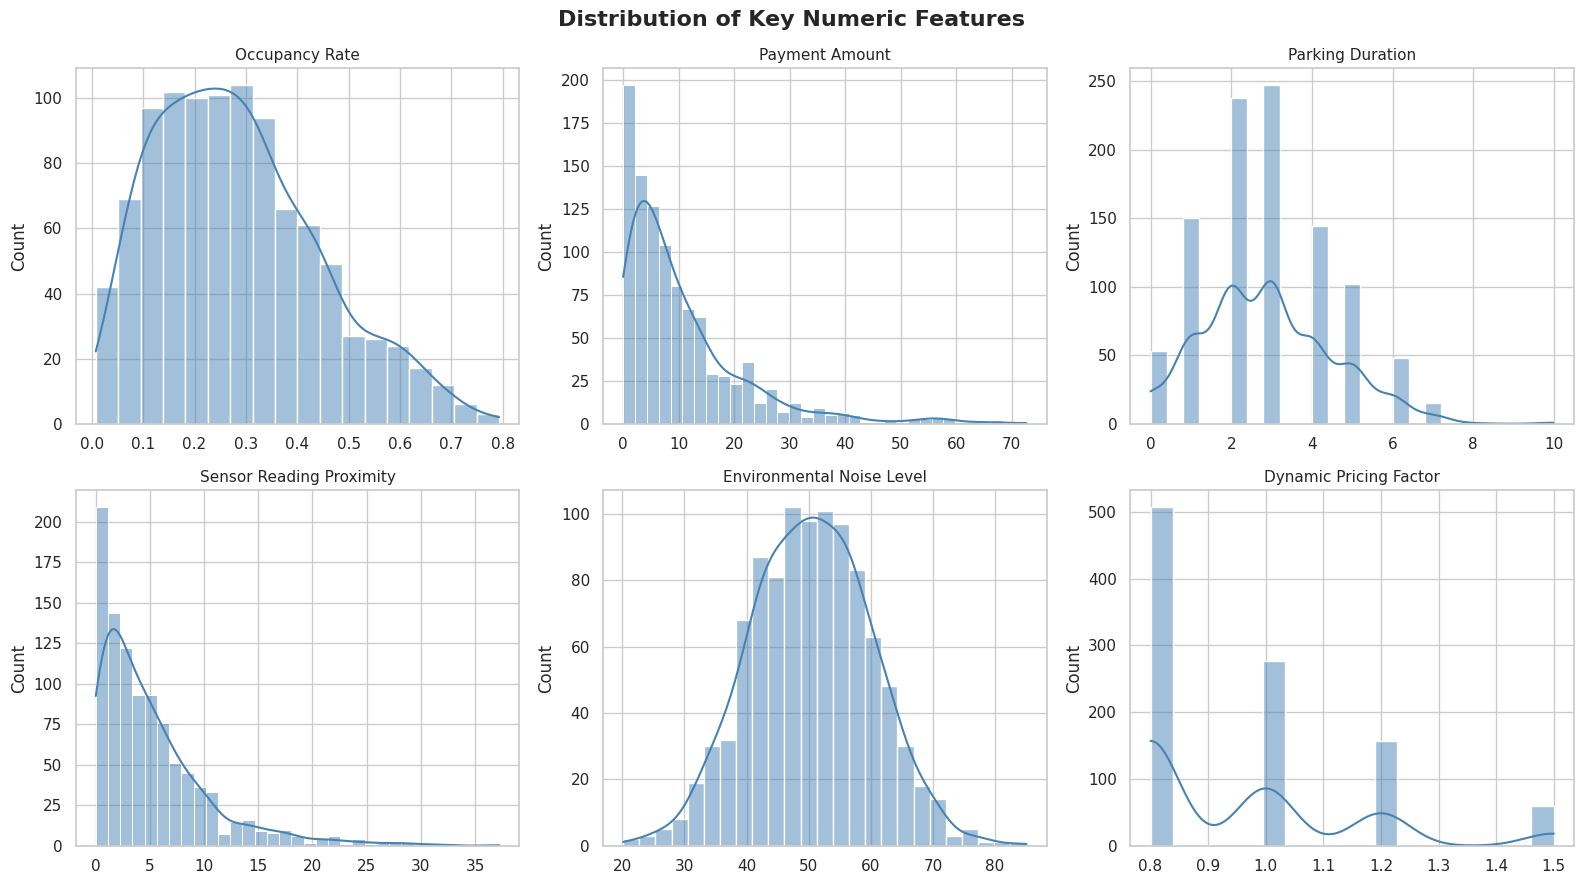

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution of Key Numeric Features', fontsize=16, fontweight='bold')

cols = ['Occupancy_Rate', 'Payment_Amount', 'Parking_Duration',
        'Sensor_Reading_Proximity', 'Environmental_Noise_Level', 'Dynamic_Pricing_Factor']

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_', ' '), fontsize=11)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('01_univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3141/2644602119.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, order=order, palette='Set2')
/tmp/ipykernel_3141/2644602119.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, order=order, palette='Set2')
/tmp/ipykernel_3141/2644602119.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, order=order, palette='Set2')
/tmp/ipykernel_3141/2644602119.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

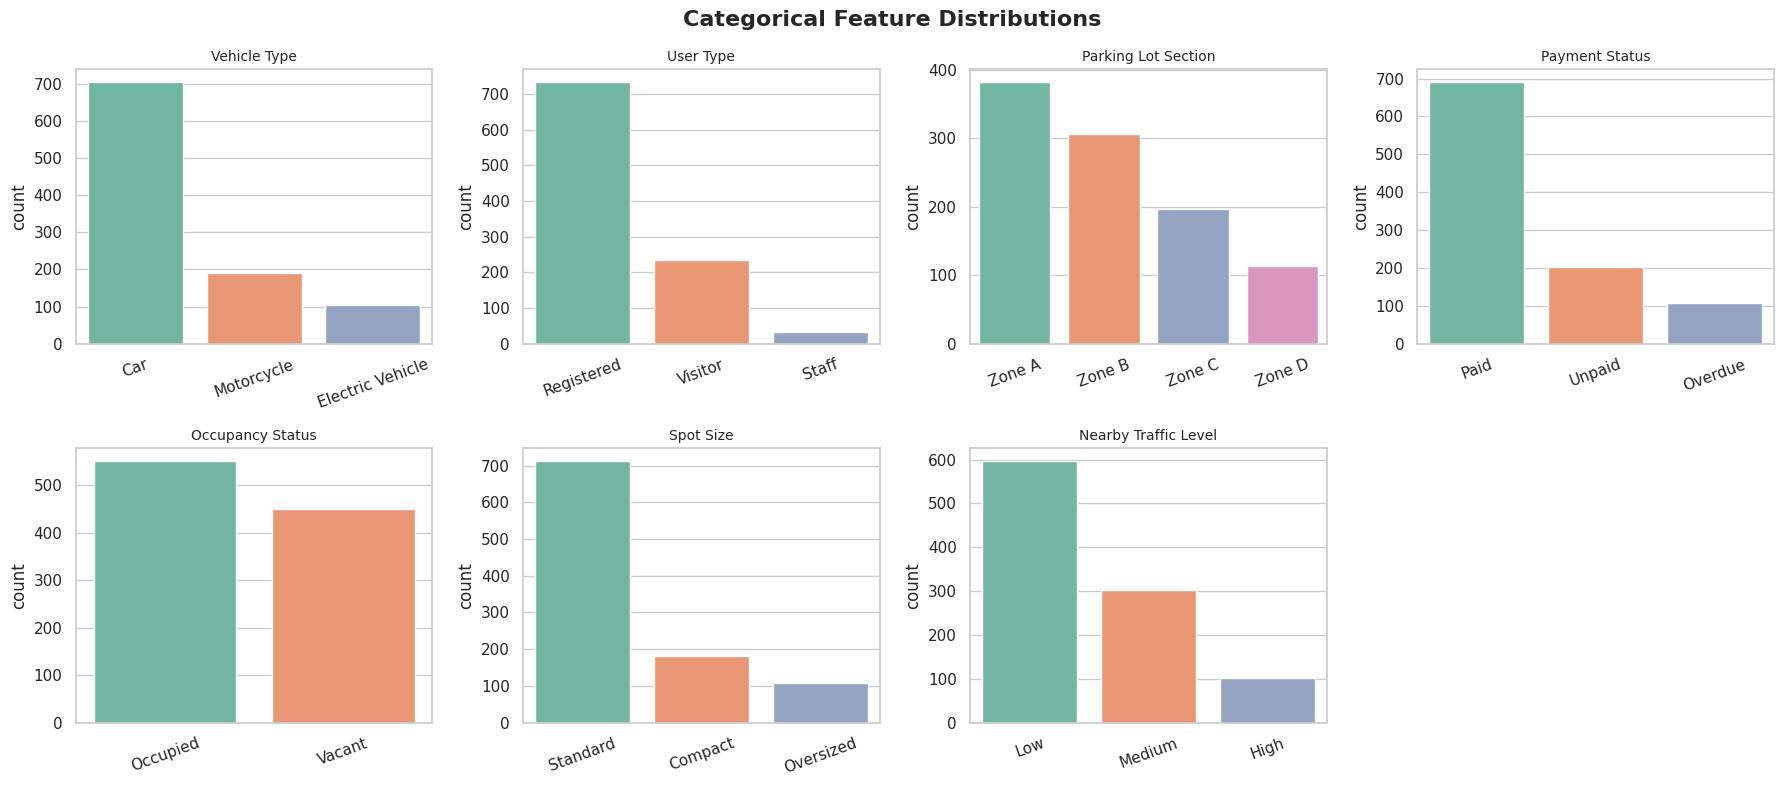

In [11]:
cat_cols = ['Vehicle_Type', 'User_Type', 'Parking_Lot_Section',
            'Payment_Status', 'Occupancy_Status', 'Spot_Size', 'Nearby_Traffic_Level']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=ax, order=order, palette='Set2')
    ax.set_title(col.replace('_', ' '), fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

axes[1, 3].set_visible(False)   # hide empty subplot
plt.tight_layout()
plt.savefig('02_categorical_counts.png', dpi=150, bbox_inches='tight')
plt.show()

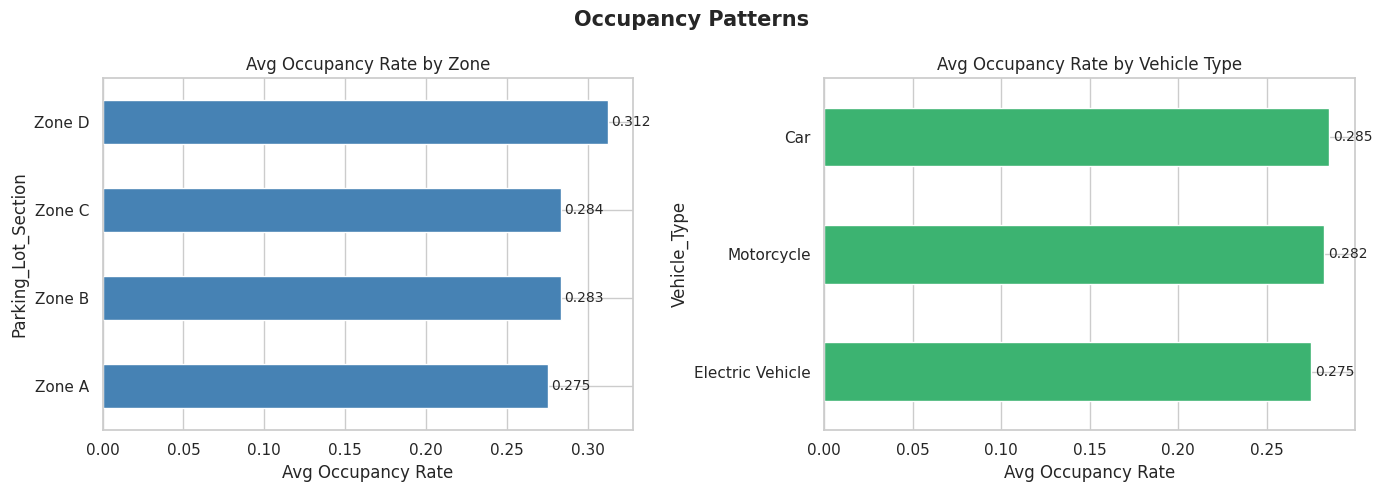

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Occupancy Patterns', fontsize=15, fontweight='bold')

# By Zone
zone_occ = df.groupby('Parking_Lot_Section')['Occupancy_Rate'].mean().sort_values()
zone_occ.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Avg Occupancy Rate by Zone')
axes[0].set_xlabel('Avg Occupancy Rate')
for i, v in enumerate(zone_occ):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)

# By Vehicle Type
veh_occ = df.groupby('Vehicle_Type')['Occupancy_Rate'].mean().sort_values()
veh_occ.plot(kind='barh', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Avg Occupancy Rate by Vehicle Type')
axes[1].set_xlabel('Avg Occupancy Rate')
for i, v in enumerate(veh_occ):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('03_occupancy_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

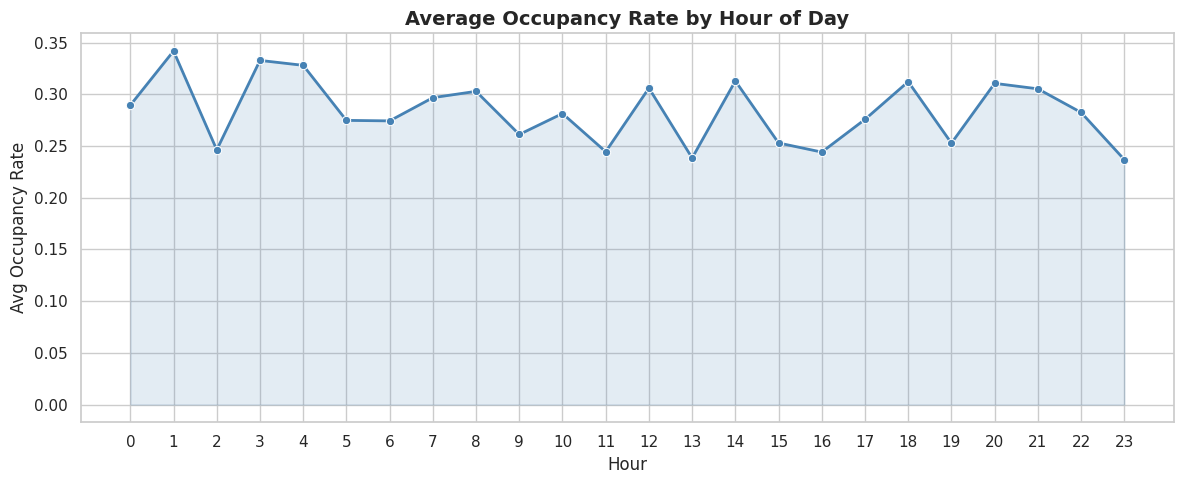

In [13]:
hourly = df.groupby('hour')['Occupancy_Rate'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly, x='hour', y='Occupancy_Rate',
             marker='o', color='steelblue', linewidth=2)
plt.fill_between(hourly['hour'], hourly['Occupancy_Rate'], alpha=0.15, color='steelblue')
plt.title('Average Occupancy Rate by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Avg Occupancy Rate')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('04_occupancy_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3141/2084630311.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Occupancy_Status', y=col,
/tmp/ipykernel_3141/2084630311.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Occupancy_Status', y=col,
/tmp/ipykernel_3141/2084630311.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Occupancy_Status', y=col,


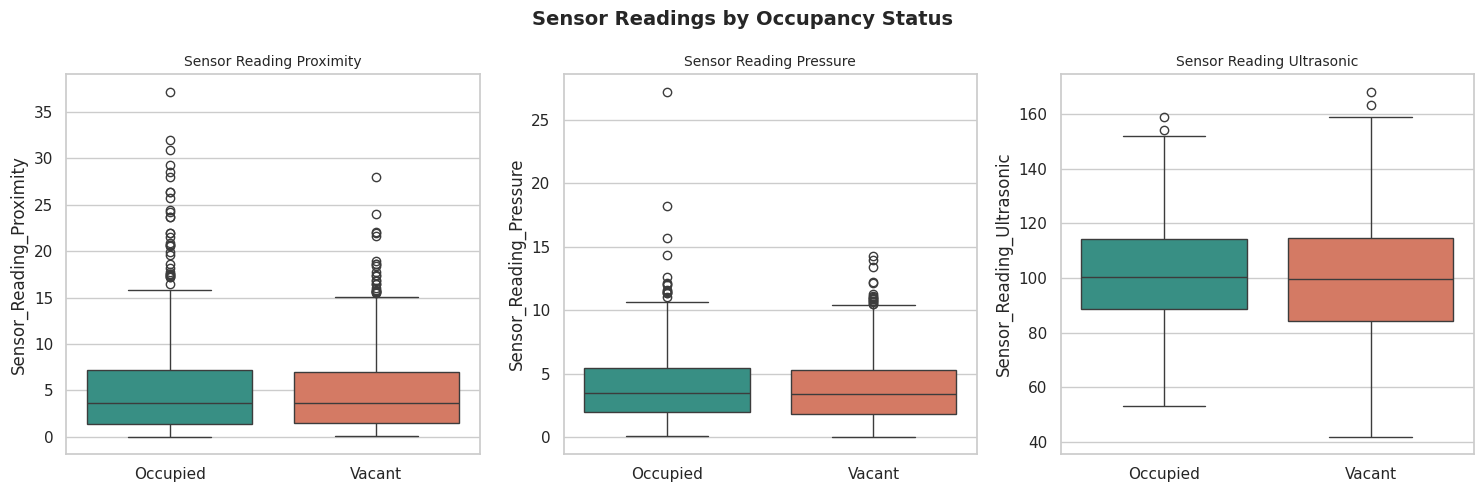

In [14]:
sensor_cols = ['Sensor_Reading_Proximity', 'Sensor_Reading_Pressure',
               'Sensor_Reading_Ultrasonic']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sensor Readings by Occupancy Status', fontsize=14, fontweight='bold')

for ax, col in zip(axes, sensor_cols):
    sns.boxplot(data=df, x='Occupancy_Status', y=col,
                palette={'Occupied': '#2a9d8f', 'Vacant': '#e76f51'}, ax=ax)
    ax.set_title(col.replace('_', ' '), fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('06_sensor_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

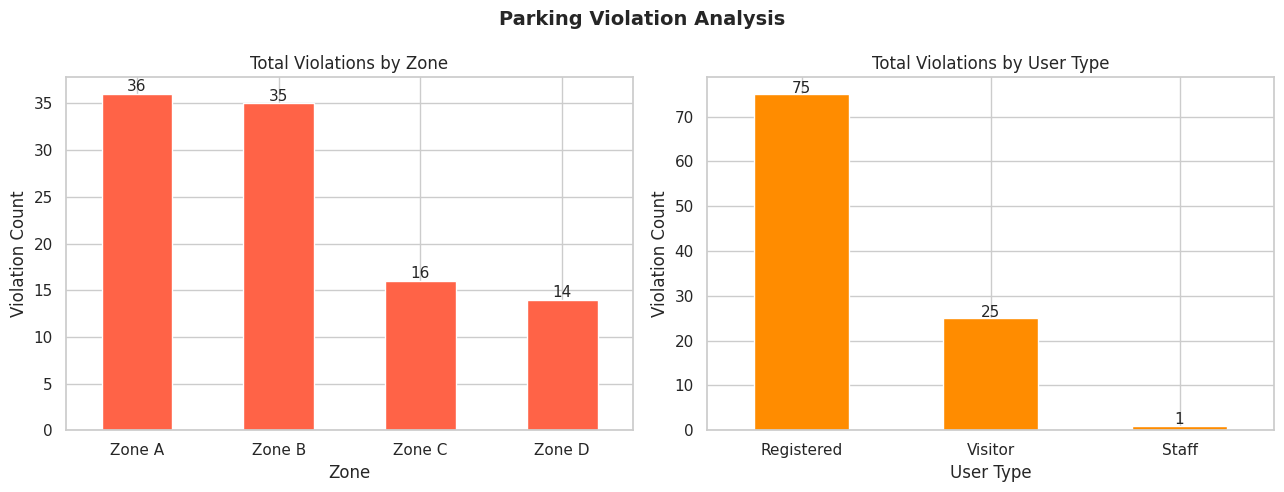

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Parking Violation Analysis', fontsize=14, fontweight='bold')

# Violations by zone
viol_zone = df.groupby('Parking_Lot_Section')['Parking_Violation'].sum().sort_values(ascending=False)
viol_zone.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Total Violations by Zone')
axes[0].set_xlabel('Zone')
axes[0].set_ylabel('Violation Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(viol_zone):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=11)

# Violations by user type
viol_user = df.groupby('User_Type')['Parking_Violation'].sum().sort_values(ascending=False)
viol_user.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Total Violations by User Type')
axes[1].set_xlabel('User Type')
axes[1].set_ylabel('Violation Count')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(viol_user):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('07_violation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

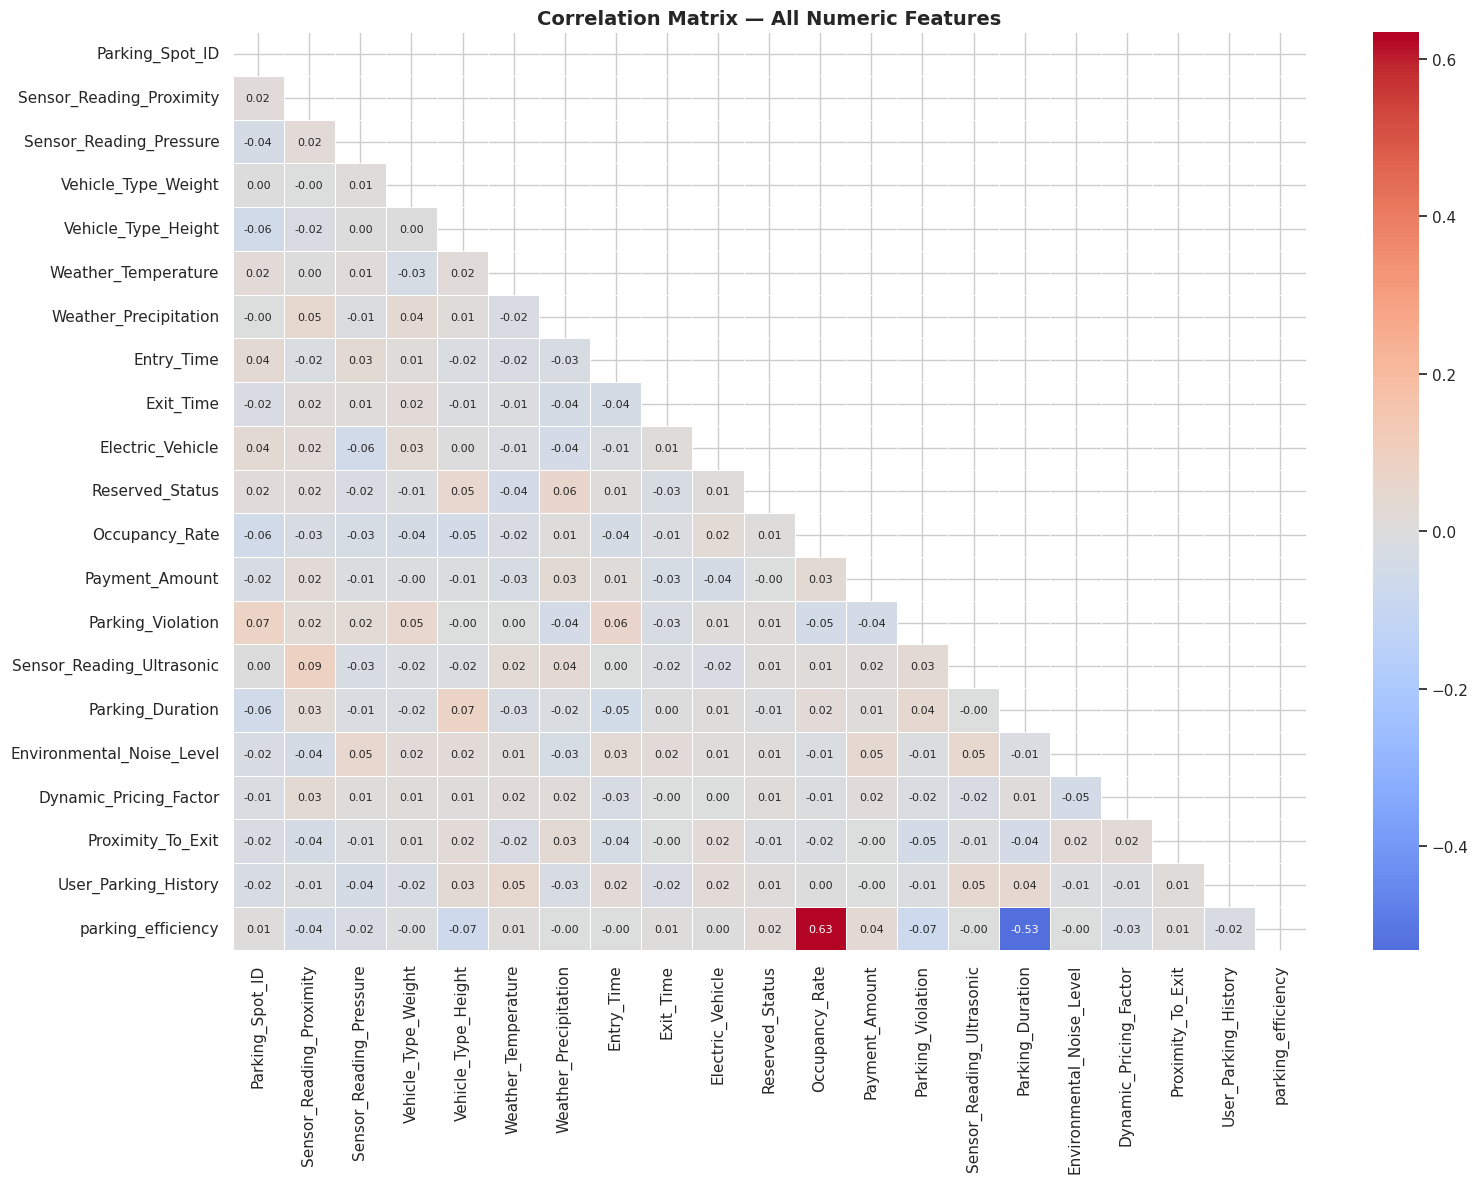

In [16]:
# Select all numeric columns
num_df = df.select_dtypes(include=np.number).drop(
    columns=['day_of_week', 'month', 'hour', 'is_peak_hour']  # added features, keep EDA clean
)

corr = num_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8})
plt.title('Correlation Matrix — All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

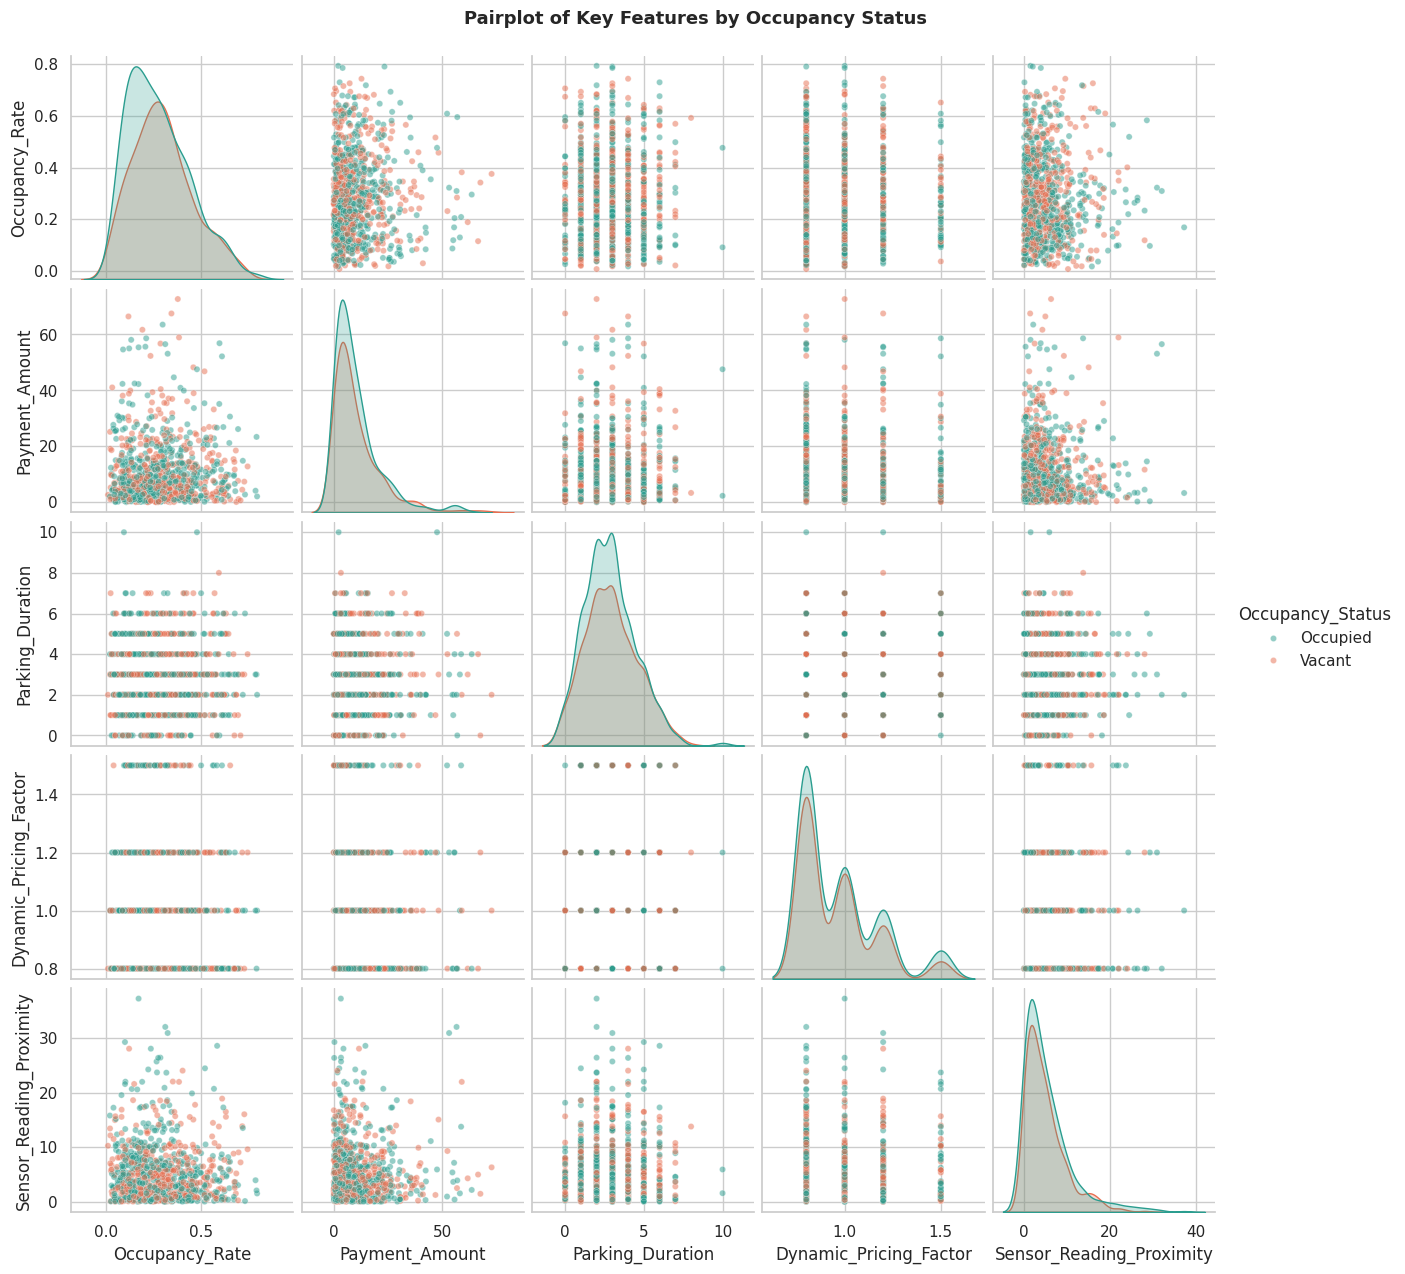

In [17]:
# Select most important features for pairplot
pair_cols = ['Occupancy_Rate', 'Payment_Amount', 'Parking_Duration',
             'Dynamic_Pricing_Factor', 'Sensor_Reading_Proximity']

sns.pairplot(df[pair_cols + ['Occupancy_Status']],
             hue='Occupancy_Status',
             palette={'Occupied': '#2a9d8f', 'Vacant': '#e76f51'},
             plot_kws={'alpha': 0.5, 's': 20},
             diag_kind='kde')
plt.suptitle('Pairplot of Key Features by Occupancy Status', y=1.02,
             fontsize=13, fontweight='bold')
plt.savefig('09_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


  Logistic Regression
  Accuracy : 0.5150
  ROC-AUC  : 0.5051
              precision    recall  f1-score   support

      Vacant       0.45      0.37      0.40        90
    Occupied       0.55      0.64      0.59       110

    accuracy                           0.52       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.51      0.52      0.51       200


  Random Forest
  Accuracy : 0.5500
  ROC-AUC  : 0.5159
              precision    recall  f1-score   support

      Vacant       0.50      0.32      0.39        90
    Occupied       0.57      0.74      0.64       110

    accuracy                           0.55       200
   macro avg       0.54      0.53      0.52       200
weighted avg       0.54      0.55      0.53       200


  Gradient Boosting
  Accuracy : 0.5000
  ROC-AUC  : 0.5104
              precision    recall  f1-score   support

      Vacant       0.43      0.33      0.38        90
    Occupied       0.54      0.64      0.58       110

 

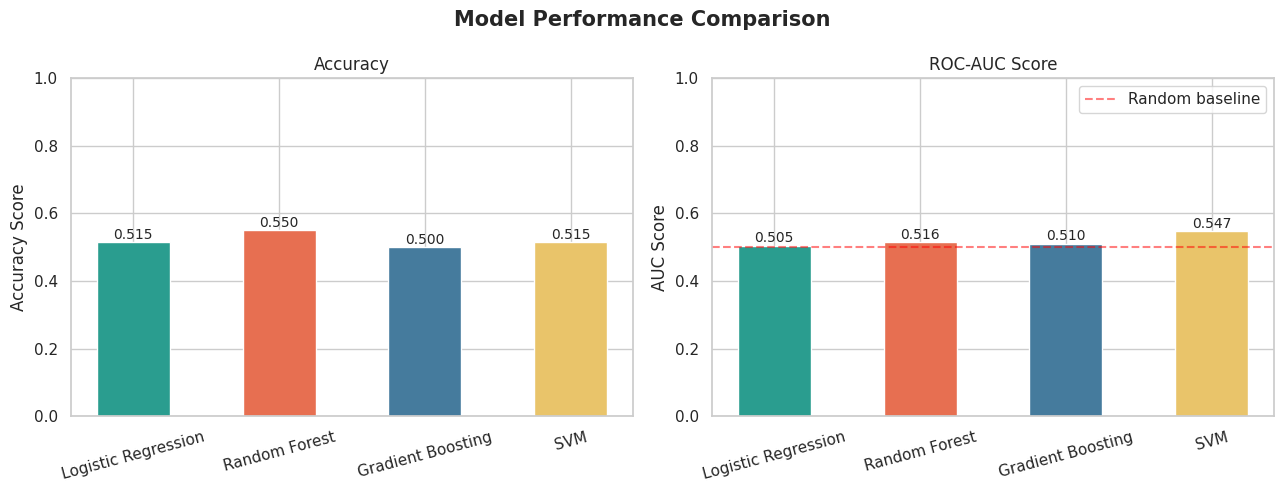

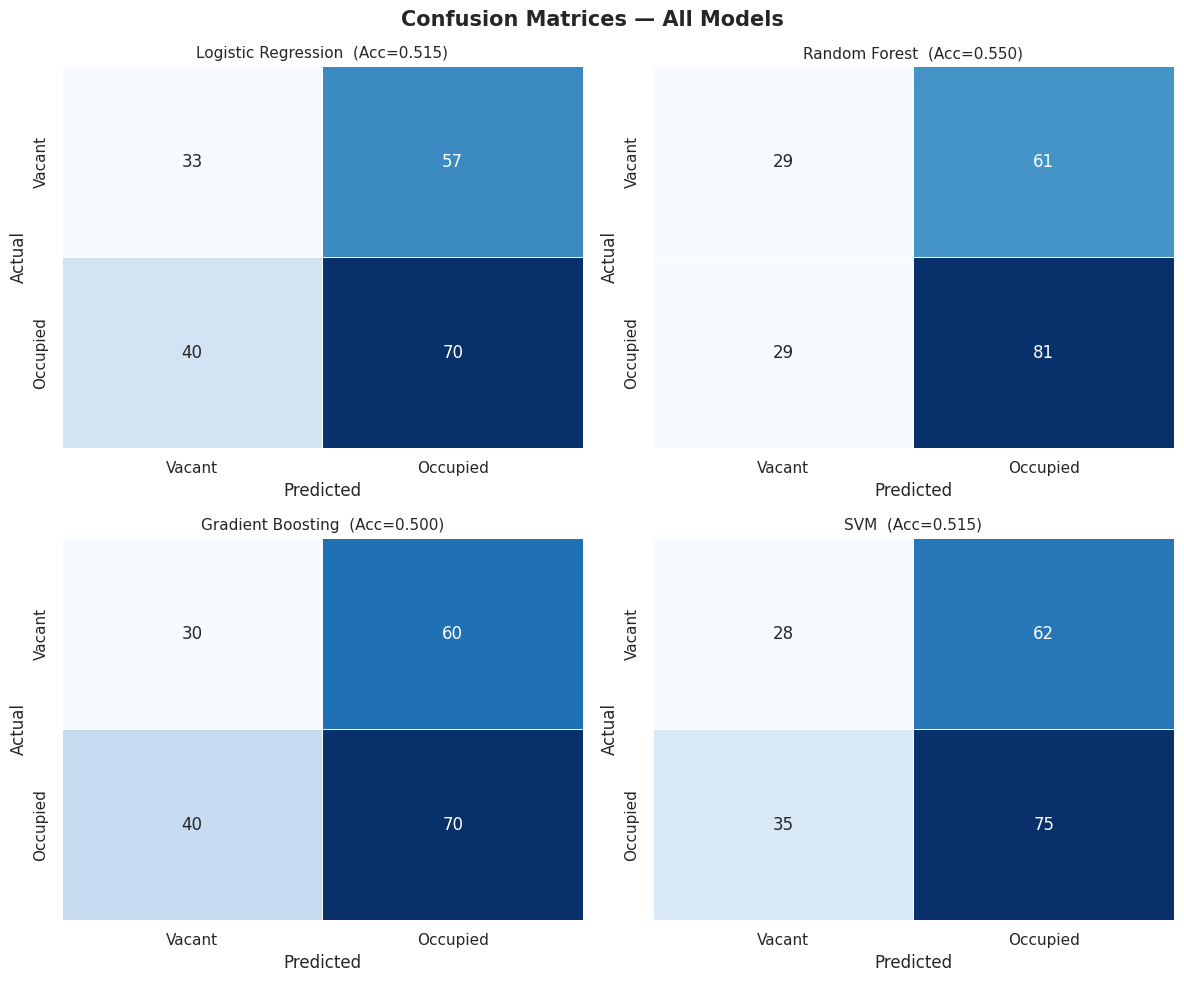

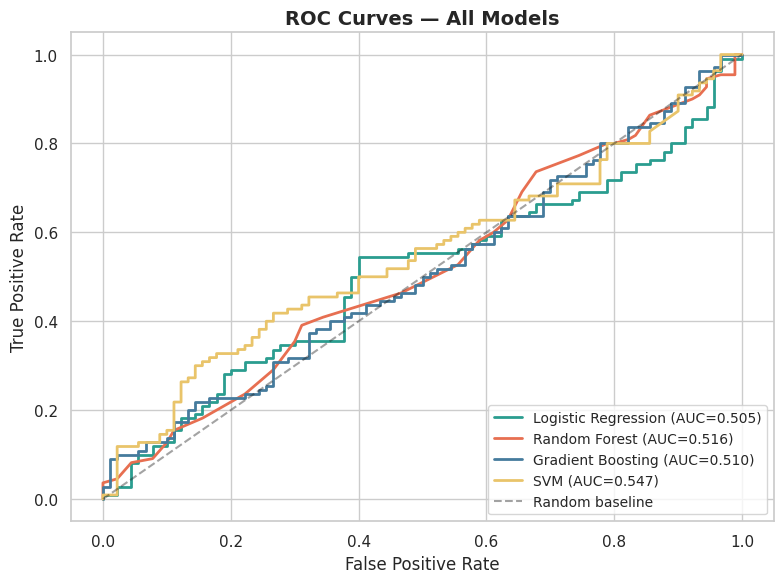

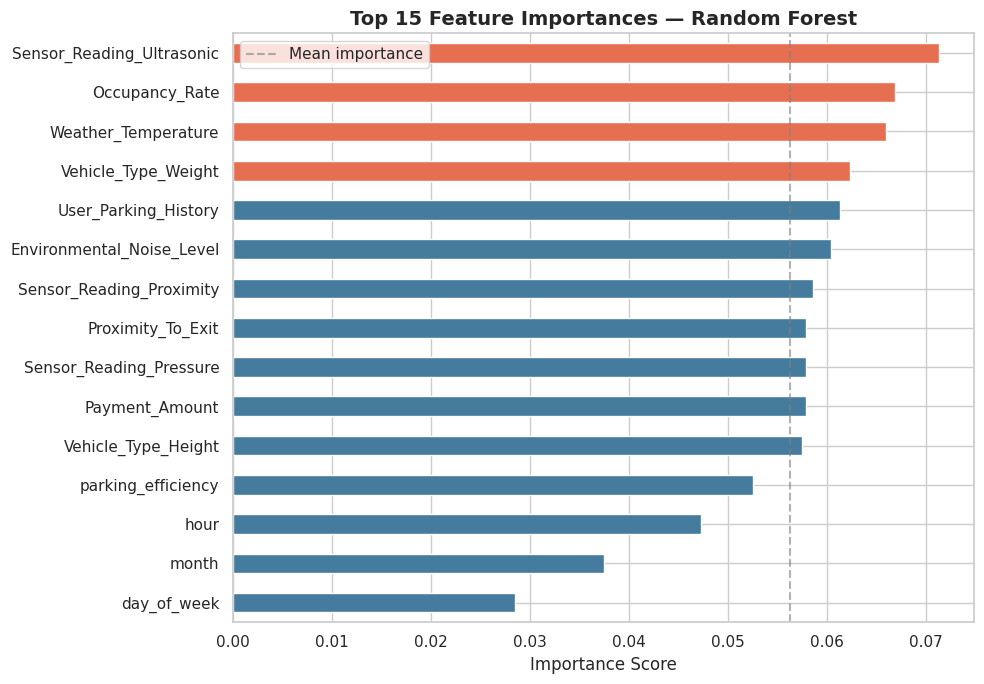

In [18]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Preprocessing (carry over from Phase 1) ────────────────────────────────
df = pd.read_csv('IIoT_Smart_Parking_Management.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour']            = df['Timestamp'].dt.hour
df['day_of_week']     = df['Timestamp'].dt.dayofweek
df['month']           = df['Timestamp'].dt.month
df['parking_efficiency'] = df['Occupancy_Rate'] / (df['Parking_Duration'] + 1)
df['is_peak_hour']    = df['hour'].apply(lambda x: 1 if (7<=x<=9 or 17<=x<=20) else 0)

cat_cols = ['User_Type','Nearby_Traffic_Level','Parking_Lot_Section',
            'Payment_Status','Vehicle_Type','Spot_Size']
le = LabelEncoder()
for col in cat_cols:
    df[col+'_enc'] = le.fit_transform(df[col])

# Target: predict whether a spot is Occupied or Vacant
df['Occupancy_enc'] = (df['Occupancy_Status'] == 'Occupied').astype(int)

# ── Feature Selection ──────────────────────────────────────────────────────
feature_cols = [
    'Sensor_Reading_Proximity', 'Sensor_Reading_Pressure', 'Sensor_Reading_Ultrasonic',
    'Vehicle_Type_Weight', 'Vehicle_Type_Height', 'Weather_Temperature',
    'Weather_Precipitation', 'Occupancy_Rate', 'Payment_Amount', 'Parking_Duration',
    'Environmental_Noise_Level', 'Dynamic_Pricing_Factor', 'Proximity_To_Exit',
    'User_Parking_History', 'Electric_Vehicle', 'Reserved_Status', 'Parking_Violation',
    'hour', 'day_of_week', 'month', 'parking_efficiency', 'is_peak_hour',
    'User_Type_enc', 'Nearby_Traffic_Level_enc', 'Parking_Lot_Section_enc',
    'Payment_Status_enc', 'Vehicle_Type_enc', 'Spot_Size_enc'
]

X = df[feature_cols]
y = df['Occupancy_enc']

# ── Train/Test Split (80/20, stratified) ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling (needed for LR and SVM, optional for tree models)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Define Models ──────────────────────────────────────────────────────────
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42),      True),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, random_state=42), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=100, random_state=42), False),
    'SVM':                 (SVC(kernel='rbf', probability=True, random_state=42),     True),
}

# ── Train & Evaluate All Models ────────────────────────────────────────────
results = {}
for name, (model, use_scaled) in models.items():
    Xtr = X_train_sc if use_scaled else X_train.values
    Xte = X_test_sc  if use_scaled else X_test.values
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    results[name] = {
        'model': model, 'preds': preds, 'proba': proba,
        'acc':   accuracy_score(y_test, preds),
        'auc':   roc_auc_score(y_test, proba),
        'cm':    confusion_matrix(y_test, preds),
    }
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"  Accuracy : {results[name]['acc']:.4f}")
    print(f"  ROC-AUC  : {results[name]['auc']:.4f}")
    print(classification_report(y_test, preds, target_names=['Vacant', 'Occupied']))

# ── Plot 1: Model Comparison Bar Chart ────────────────────────────────────
names  = list(results.keys())
accs   = [results[n]['acc'] for n in names]
aucs   = [results[n]['auc'] for n in names]
colors = ['#2a9d8f','#e76f51','#457b9d','#e9c46a']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

for ax, values, title, ylabel in zip(
        axes, [accs, aucs],
        ['Accuracy', 'ROC-AUC Score'], ['Accuracy Score', 'AUC Score']):
    bars = ax.bar(names, values, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title); ax.set_ylim(0, 1); ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}',
                ha='center', fontsize=10)

axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
axes[1].legend()
plt.tight_layout()
plt.savefig('10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Confusion Matrices ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
for ax, name in zip(axes.flatten(), names):
    sns.heatmap(results[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Vacant','Occupied'],
                yticklabels=['Vacant','Occupied'],
                linewidths=0.5, linecolor='white', cbar=False)
    ax.set_title(f"{name}  (Acc={results[name]['acc']:.3f})", fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: ROC Curves ─────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
for name, color in zip(names, colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['proba'])
    plt.plot(fpr, tpr,
             label=f"{name} (AUC={results[name]['auc']:.3f})",
             color=color, linewidth=2)
plt.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random baseline')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('12_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 4: Feature Importance (Random Forest) ─────────────────────────────
rf_model    = results['Random Forest']['model']
importances = (pd.Series(rf_model.feature_importances_, index=feature_cols)
               .sort_values(ascending=True).tail(15))
bar_colors  = ['#e76f51' if v >= importances.quantile(0.75) else '#457b9d'
               for v in importances]

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color=bar_colors, edgecolor='white')
plt.axvline(importances.mean(), color='gray', linestyle='--',
            alpha=0.6, label='Mean importance')
plt.title('Top 15 Feature Importances — Random Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score'); plt.legend()
plt.tight_layout()
plt.savefig('13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()